See [here](https://duckdb.org/docs/stable/guides/python/jupyter) for the following configs.

In [1]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False 

In [2]:
import duckdb
import altair as alt
from IPython.display import Image, display

alt.renderers.enable('default')
alt.data_transformers.enable('default')

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

Tip: You may define configurations in /gpfs1/home/j/s/jstonge1/scisciDB/pyproject.toml or /users/j/s/jstonge1/.jupysql/config.

Did not find user configurations in /gpfs1/home/j/s/jstonge1/scisciDB/pyproject.toml.

In [3]:
%%sql
INSTALL ducklake;
LOAD ducklake;
ATTACH 'ducklake:metadata.ducklake' AS scisciDB (DATA_PATH '/gpfs1/home/j/s/jstonge1/data/scisciDB/');
USE scisciDB;

,Success


Let's first examine what just happened. We attached ourselves to a DuckLake, created in `load/load.py`. DuckLakes are nice because they provide version control history for data in the form of catalogs. That is, a set of tables in charge of tracking everything that is happening to your database: how the schema is evolving, what has been removed or added, how we might partition the data, etc. This tracking provides us with the ability to audit any step, and, if necessary, travel back to specific versions along the way. But this comes at a price; we need to be mindful about what is happening under the hood. Catalogs are tracking any commit made to your DuckLake in the form of snapshots. If you are appending your values one by one, instead of batching, then you will create as many snapshots as there are inserted values. This, in turn, is stored in your catalogs so it will increase significantly catalog sizes. We will see how to manage that as well. We will put aside the theory and just dive right into working with catalogs and duckdb.

Jupyter extension on VScode, for some reason, refuses to display all the tables with the simple command `SHOW ALL TABLES;`.

In [4]:
%sql select database_name, table_name from duckdb_tables() limit 10;

,database_name,table_name
0,__ducklake_metadata_scisciDB,ducklake_column
1,__ducklake_metadata_scisciDB,ducklake_column_mapping
2,__ducklake_metadata_scisciDB,ducklake_column_tag
3,__ducklake_metadata_scisciDB,ducklake_data_file
4,__ducklake_metadata_scisciDB,ducklake_delete_file
5,__ducklake_metadata_scisciDB,ducklake_files_scheduled_for_deletion
6,__ducklake_metadata_scisciDB,ducklake_file_column_stats
7,__ducklake_metadata_scisciDB,ducklake_file_partition_value
8,__ducklake_metadata_scisciDB,ducklake_inlined_data_tables
9,__ducklake_metadata_scisciDB,ducklake_metadata


In [5]:
%sql SELECT * FROM __ducklake_metadata_scisciDB.ducklake_metadata;

,key,value,scope,scope_id
0,version,0.3,None,<NA>
1,created_by,DuckDB 68d7555f68,None,<NA>
2,data_path,/gpfs1/home/j/s/jstonge1/data/scisciDB/,None,<NA>
3,encrypted,false,None,<NA>


We can inspect table metadata just from the catalog

In [6]:
%%sql 
SELECT * 
    EXCLUDE(table_uuid, end_snapshot, table_name, path_is_relative, table_id), 
    (file_size_bytes / 1e9) as file_size_GB
FROM __ducklake_metadata_scisciDB.ducklake_table t
LEFT JOIN __ducklake_metadata_scisciDB.ducklake_table_stats s ON t.table_id = s.table_id;

,begin_snapshot,schema_id,path,record_count,next_row_id,file_size_bytes,file_size_GB
0,1,0,s2_papers/,230523503,230523503,54712559253,54.712559
1,2,0,s2_publication_venues/,389156,389156,38047833,0.038048
2,3,0,s2_authors/,111895305,111895305,5358952145,5.358952


## Inspect `s2_papers`

In [7]:
%%sql
select count(*) as total_papers from scisciDB.s2_papers;

,total_papers
0,230523503


In [8]:
%%sql 
count_df << SELECT 
    COUNT(*) as n, year 
    FROM scisciDB.s2_papers 
    WHERE 
        year IS NOT NULL AND year > 1900
    GROUP BY year;

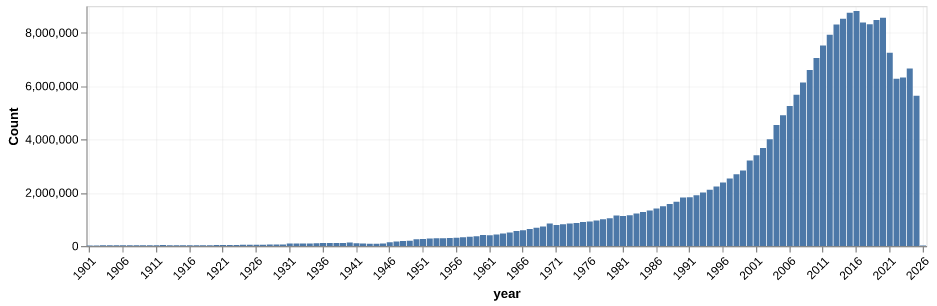

In [9]:
alt.Chart(count_df).mark_bar().encode(
    x=alt.X('year:O', 
            axis=alt.Axis(labelAngle=-45, 
                         values=list(count_df['year'][::5]))),  # Show every 5th year
    y=alt.Y('n:Q', title='Count'),
    tooltip=['year:O', 'n:Q']
).properties(
    width=700,
    height=200
).configure_axis(
    grid=True,
    gridOpacity=0.3
).save('chart.png', scale_factor=1.2)

Image('chart.png')

This is pretty damn cool. I cannot overemphasize enough how it used to be more messy than that to do this count.

Just take a moment to realize what we just accomplished; in 2.3s, we analyze 270G worth of paper data and we only have 46G of RAM on the current node. We did that thanks to duckdb, but then with the `sql` magic in jupyter notebook we could produce an interactive visualization using `altair`. This is just amazing for exploring big-ish datasets.

Say that we want to know the proportion for which we have parsed text? Although this is conceptually simple question, it is technically made more challenging by the fact that we need to somehow know which papers has been parsed or not. The thing is that `s2_papers` don't have this field in the raw data, but we know which papers has been parsed by looking at the `s2orc_v2` table, containing the full-body parsed text. Usually, this is a simple join, where we look up `corpusid` on both tables; but here this join involves tow large tables; 270Gb and ?. 

But this is no problem for duckdb! We can just do something like without using that much RAM

In [13]:
# %%sql
# ALTER TABLE scisciDB.s2_papers ADD COLUMN has_fulltext BOOLEAN;
# UPDATE scisciDB.s2_papers AS p
# SET has_fulltext = EXISTS (
#     SELECT 1 FROM scisciDB.s2orc_v2 AS o
#     WHERE o.corpusid = p.corpusid
# );

In [13]:
%%sql
CREATE VIEW s2_papers_enriched AS
SELECT 
    p.*,
    EXISTS (SELECT 1 FROM scisciDB.s2orc_v2 o WHERE o.corpusid = p.corpusid) as has_fulltext
FROM scisciDB.s2_papers p;

,Count


In [14]:
%sql SELECT * FROM s2_papers_enriched LIMIT 5;

,corpusid,externalids,url,title,authors,venue,publicationvenueid,year,referencecount,citationcount,influentialcitationcount,isopenaccess,s2fieldsofstudy,publicationtypes,publicationdate,journal,has_fulltext
0,223476054,"{'MAG': '570827548', 'CorpusId': '223476054', ...",https://www.semanticscholar.org/paper/1f0fa44e...,"〔都市問題〕文献情報(図書昭和53年3月受入,雑誌昭和52年12月〜昭和53年3月受入)","[{'authorId': '135789101', 'name': '市政専門図書館'}]",,<NA>,1978,0,0,0,False,<NA>,<NA>,1978-05-01,"{'name': '', 'pages': '127-145', 'volume': '69'}",False
1,98189215,"{'MAG': '2091042102', 'CorpusId': '98189215', ...",https://www.semanticscholar.org/paper/e4d61ff5...,Nonreactivity of rydberg states woodward-hoffm...,"[{'authorId': '14243869', 'name': 'K. Wittel'}]",,<NA>,1977,19,1,0,False,"[{'category': 'Chemistry', 'source': 's2-fos-m...",<NA>,NaT,"{'name': 'Tetrahedron', 'pages': '2687-2689', ...",False
2,223204962,"{'MAG': '1989126529', 'CorpusId': '223204962',...",https://www.semanticscholar.org/paper/b98dc198...,George Hoggart Toulmin: politics and geology,"[{'authorId': '144440725', 'name': 'R. Porter'}]",,<NA>,1978,0,0,0,False,<NA>,<NA>,1978-05-01,{'name': 'Journal of the Society for the Bibli...,False
3,270461887,"{'MAG': None, 'CorpusId': '270461887', 'ACL': ...",https://www.semanticscholar.org/paper/76bdb784...,Materials Engineers,[],,<NA>,1974,0,0,0,True,<NA>,[Editorial],1974-01-01,"{'name': 'British Corrosion Journal', 'pages':...",False
4,98016413,"{'MAG': '2076045973', 'CorpusId': '98016413', ...",https://www.semanticscholar.org/paper/60531164...,Ergebnisse der Tieftemperaturforschung XXXVIII...,"[{'authorId': '17118849', 'name': 'K. Clusius'...",,<NA>,1962,0,6,0,False,<NA>,<NA>,1962-06-01,"{'name': 'Zeitschrift für Naturforschung A', '...",False


In [17]:
%%sql
fulltext_df << SELECT 
    year,
    COUNT(*) as total_papers,
    COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,
    COUNT(*) FILTER (WHERE NOT has_fulltext) as papers_without_fulltext
    FROM s2_papers_enriched 
    WHERE year IS NOT NULL AND year > 1900
    GROUP BY year
    ORDER BY year;

Here it will be a bit slower that what it could be if we had altered the `s2_papers` with the column `has_fulltext`. But if we did that, our catalogs would have registered that alteration, creating a duplicated dataset as this alteration is impacting all the rows of our `s2_papers` schema. This is how we get the possibility to travel back in time with catalogs, but this come at the cost of extra storage. In this case, using a VIEW we're avoiding writing new parquets. For now, this is fine. I don't think I am gonna run this query often, but if I would, I might materialize this view into the table and accept that the tradeoff. 

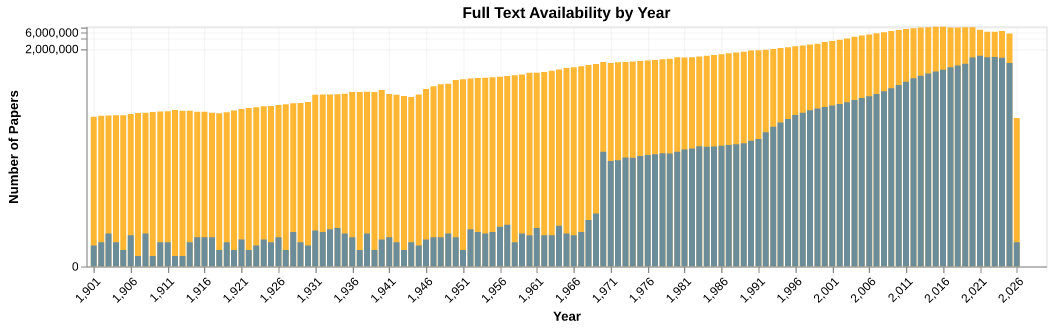

In [18]:
# Create base chart
base = alt.Chart(fulltext_df).encode(
    x=alt.X('year:Q',
            axis=alt.Axis(labelAngle=-45, values=list(fulltext_df['year'][::5])),
            title='Year')
)

# Bottom bar (total) - orange
bottom = base.mark_bar(color='orange', opacity=0.8).encode(
    y=alt.Y('total_papers:Q',
            scale=alt.Scale(type='symlog'),
            title='Number of Papers'),
    tooltip=['year', 'total_papers']
)

# Top bar (with fulltext) - blue
top = base.mark_bar(color='steelblue', opacity=0.8).encode(
    y=alt.Y('papers_with_fulltext:Q',
            scale=alt.Scale(type='symlog')),
    tooltip=['year', 'papers_with_fulltext']
)

(bottom + top).properties(
    width=800,
    height=200,
    title='Full Text Availability by Year'
).configure_axis(
    grid=True,
    gridOpacity=0.3
).save('chart.png', scale_factor=1.2)

Image('chart.png')

In [19]:
plan_html = conn.execute("""
EXPLAIN ANALYZE
SELECT 
    year,
    COUNT(*) as total_papers,
    COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,
    COUNT(*) FILTER (WHERE NOT has_fulltext) as papers_without_fulltext
    FROM s2_papers_enriched 
    WHERE year IS NOT NULL AND year > 1900
    GROUP BY year
    ORDER BY year;
""").fetchall()


for row in plan_html:
    print(row[1])



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
 EXPLAIN ANALYZE SELECT      year,     COUNT(*) as total_papers,     COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,     COUNT(*) FILTER (WHERE NOT has_fulltext) as papers_without_fulltext     FROM s2_papers_enriched      WHERE year IS NOT NULL AND year > 1900     GROUP BY year     ORDER BY year; 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││              Total Time: 43.93s              ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│           0 rows          │
│          (0.00s)    